In [31]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, LSTM, Dense, Embedding
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
import re
from datasets import Dataset
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [3]:
df = pd.read_csv('data/Spam_SMS.csv')
df['label'] = df['Class'].map({'ham': 0, 'spam': 1})
df = df[['Message', 'label']]

In [4]:
df

,Message,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...
5569,This is the 2nd time we have tried 2 contact u...,1
5570,Will ü b going to esplanade fr home?,0
5571,"Pity, * was in mood for that. So...any other s...",0
5572,The guy did some bitching but I acted like i'd...,0


C:\Users\floco\AppData\Local\Temp\ipykernel_19484\1012058879.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')


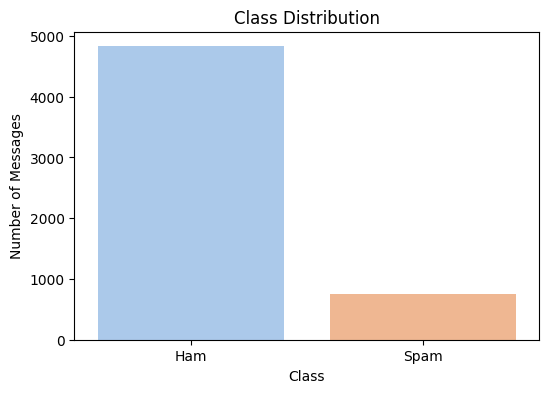

In [5]:
label_counts = df['label'].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Messages')
plt.xticks([0,1], ['Ham', 'Spam'])
plt.show()

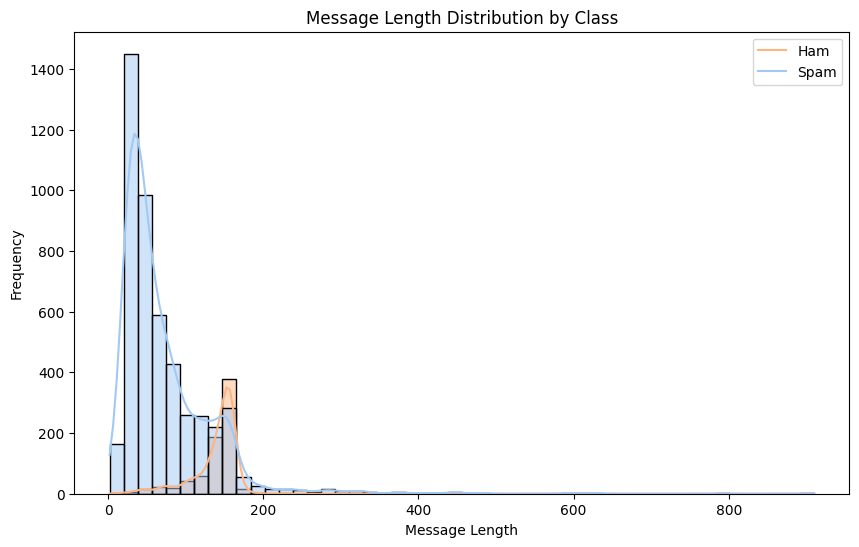

In [6]:
df['message_length'] = df['Message'].apply(len)
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='message_length', hue='label', bins=50, kde=True, palette='pastel')
plt.title('Message Length Distribution by Class')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.legend(['Ham', 'Spam'])
plt.show()
df = df.drop(["message_length"], axis=1)

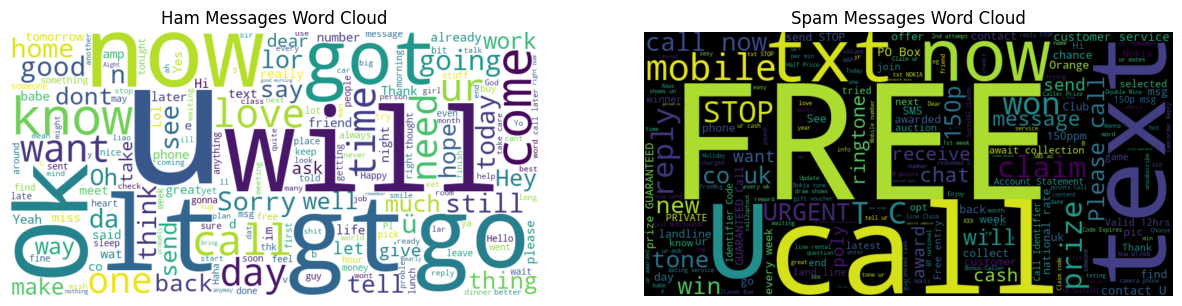

In [7]:
ham_words = ' '.join(df[df['label'] == 0]['Message'])
wordcloud_ham = WordCloud(width=800, height=400, background_color='white').generate(ham_words)
spam_words = ' '.join(df[df['label'] == 1]['Message'])
wordcloud_spam = WordCloud(width=800, height=400, background_color='black').generate(spam_words)

plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.axis('off')
plt.title('Ham Messages Word Cloud')

plt.subplot(1,2,2)
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.axis('off')
plt.title('Spam Messages Word Cloud')
plt.show()

In [8]:
df = pd.read_csv('data/Spam_SMS.csv')

In [9]:
X=df.drop("Class",axis=1)
y=df["Class"]

In [10]:
message=X.copy()
message

,Message
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."
...,...
5569,This is the 2nd time we have tried 2 contact u...
5570,Will ü b going to esplanade fr home?
5571,"Pity, * was in mood for that. So...any other s..."
5572,The guy did some bitching but I acted like i'd...


Prétraitement des textes (Stemming)

In [11]:
nltk.download("stopwords")
ps = PorterStemmer()
message['Message'] = message['Message'].fillna('')
corpus = []
for i in range(len(message)):
    review = str(message.iloc[i, message.columns.get_loc("Message")])
    review = re.sub("[^a-zA-Z]", " ", review)
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if not word in stopwords.words("english")]
    review = " ".join(review)
    corpus.append(review)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\floco\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Remplace les caractères non alphabétiques par des espaces (re.sub).
Convertit en minuscules.
Divise en mots.
Supprime les stop-words et applique le stemming.
Rejoint les mots en une chaîne.

Encodage one-hot et padding

In [12]:
voc_size = 1000
one_hot_repair = [one_hot(word, voc_size) for word in corpus]
max_length = max(len(item) for item in one_hot_repair)
embedding_docs = pad_sequences(one_hot_repair, padding="pre", maxlen=max_length)

one_hot encode chaque mot en un index basé sur un vocabulaire de 1000 mots.
max_length est calculé comme la longueur maximale d'une séquence (77 ici).
pad_sequences ajoute des zéros au début ("pre") pour uniformiser la longueur des séquences à 77.

Encodage des labels

In [13]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

Construction du modèle LSTM

In [14]:
embedding_vector_features = 30
model = Sequential()
model.add(Embedding(voc_size, embedding_vector_features))
model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [15]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)

In [16]:
X_final = np.array(embedding_docs)
y_final = np.array(y)
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.25, random_state=42, shuffle=True)

In [17]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), 
                    epochs=20, batch_size=32, 
                    callbacks=[early_stopping, reduce_lr])

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.8729 - loss: 0.3715 - val_accuracy: 0.9692 - val_loss: 0.1077 - learning_rate: 0.0010
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9735 - loss: 0.0843 - val_accuracy: 0.9756 - val_loss: 0.0734 - learning_rate: 0.0010
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9886 - loss: 0.0420 - val_accuracy: 0.9799 - val_loss: 0.0721 - learning_rate: 0.0010
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9948 - loss: 0.0209 - val_accuracy: 0.9799 - val_loss: 0.0755 - learning_rate: 0.0010
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9945 - loss: 0.0236 - val_accuracy: 0.9778 - val_loss: 0.0898 - learning_rate: 0.0010
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9962 - loss: 0.0149 - val_accuracy: 0.9792 - val_loss: 0.0934 - learning_rate: 2.0000e-04
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9981 - loss

<Axes: >

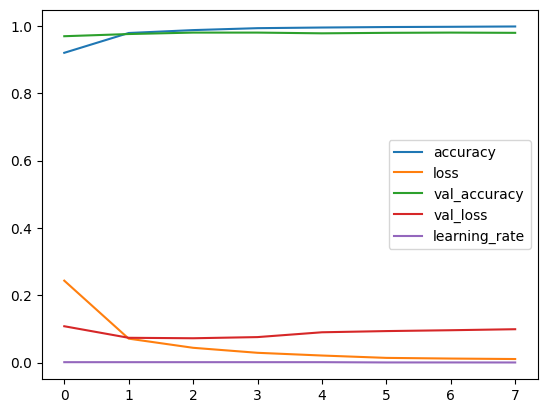

In [18]:
df2=pd.DataFrame(model.history.history)
df2.plot()

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


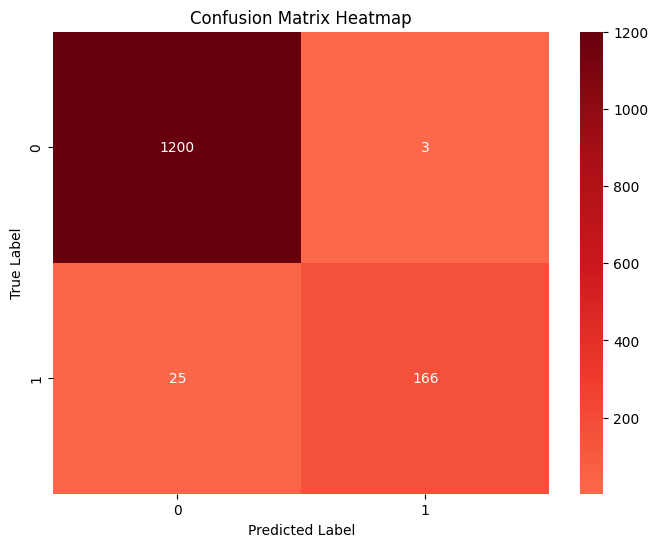

In [20]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

CM = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(CM, annot=True, fmt='d', center=0, cmap='Reds', cbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()